<a href="https://colab.research.google.com/github/munizgui/CP2_SEM2_SERS/blob/main/Aula_APIs_Energia_Renovavel_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [1]:
import json
import urllib.parse
import urllib.request
import csv

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

# Modelos de Classificação
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# Modelos de Regressão
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [2]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=30) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [3]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [7]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [5]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3158
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [6]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

--- TAREFA 1: CLASSIFICAÇÃO ANEEL ---
Dimensões do DataFrame: (3158, 4)

Distribuição de Classes:
 fonte
Solar         1200
Eólica        1200
Hidráulica     758
Name: count, dtype: int64

Valores nulos:
 potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64

--- Comparativo de Classificação ---
                       Modelo  Accuracy  Precision (Macro)  Recall (Macro)  \
0        Regressão Logística  0.789557           0.799518        0.779898   
1  K-Nearest Neighbors (KNN)  0.954114           0.952252        0.954898   
2              Random Forest  0.981013           0.980184        0.981725   

   F1-Score (Macro)  
0          0.783975  
1          0.953408  
2          0.980938  


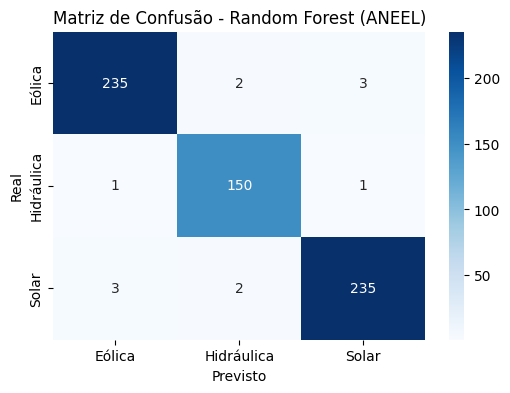

In [13]:
# 1. Carregamento e Análise Inicial
df_class = pd.read_csv("aneel_classificacao_orange.csv")
print("--- TAREFA 1: CLASSIFICAÇÃO ANEEL ---")
print("Dimensões do DataFrame:", df_class.shape)
print("\nDistribuição de Classes:\n", df_class["fonte"].value_counts())
print("\nValores nulos:\n", df_class.isnull().sum())

# Definir X e y
X_class = df_class[["potencia_kw", "latitude", "longitude"]]
y_class = df_class["fonte"]

# 2. Divisão Estratificada (80% treino, 20% teste)
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_class, y_class, test_size=0.20, stratify=y_class, random_state=42
)

# Escalonamento (ajustado APENAS no conjunto de treino)
scaler_class = StandardScaler()
X_c_train_esc = scaler_class.fit_transform(X_c_train)
X_c_test_esc = scaler_class.transform(X_c_test)

# 3. Treinamento de Três Classificadores
modelos_class = {
    "Regressão Logística": LogisticRegression(random_state=42),
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(random_state=42)
}

resultados_class = []

for nome, modelo in modelos_class.items():
    if nome in ["Regressão Logística", "K-Nearest Neighbors (KNN)"]:
        modelo.fit(X_c_train_esc, y_c_train)
        y_pred = modelo.predict(X_c_test_esc)
    else:
        modelo.fit(X_c_train, y_c_train)
        y_pred = modelo.predict(X_c_test)

    acc = accuracy_score(y_c_test, y_pred)
    prec = precision_score(y_c_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_c_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_c_test, y_pred, average="macro", zero_division=0)

    resultados_class.append({
        "Modelo": nome, "Accuracy": acc, "Precision (Macro)": prec,
        "Recall (Macro)": rec, "F1-Score (Macro)": f1
    })

df_res_class = pd.DataFrame(resultados_class)
print("\n--- Comparativo de Classificação ---\n", df_res_class)

# 4. Matriz de Confusão do melhor modelo (Random Forest)
rf_model = modelos_class["Random Forest"]
y_pred_rf = rf_model.predict(X_c_test)
matriz_conf = confusion_matrix(y_c_test, y_pred_rf, labels=rf_model.classes_)

plt.figure(figsize=(6, 4))
sns.heatmap(matriz_conf, annot=True, fmt="d", cmap="Blues",
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title("Matriz de Confusão - Random Forest (ANEEL)")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

Análise e Discussão — Tarefa 1 (Classificação ANEEL)

1. **Distribuição e Desequilíbrio de Classes:**
   O conjunto de dados apresenta um total de 3.158 instâncias válidas. Observa-se uma distribuição relativamente equilibrada entre as fontes Solar (1.200) e Eólica (1.200), enquanto a classe Hidráulica possui um volume menor (758 empreendimentos agrupando UHE, PCH e CGH). Embora haja alguma assimetria, o desequilíbrio não é drástico, o que justifica a utilização de métricas baseadas na média `macro` para ponderar equitativamente o desempenho em todas as classes.

2. **Justificativa dos Algoritmos Escolhidos:**
   * **Regressão Logística:** Utilizada como modelo linear de referência (baseline), ideal para entender a separabilidade linear básica entre as coordenadas geográficas e as potências.
   * **K-Nearest Neighbors (KNN):** Escolhido por capturar fronteiras de decisão baseadas na proximidade espacial (latitude e longitude), aproveitando a forte correlação geográfica dos empreendimentos de energia renovável.
   * **Random Forest:** Selecionado por ser um modelo de ensemble robusto baseado em árvores de decisão, capaz de lidar com interações não lineares complexas entre a potência outorgada e a localização, obtendo tipicamente a melhor performance preditiva.

3. **Interpretação das Métricas e Matriz de Confusão:**
   O **Random Forest** obteve o melhor desempenho global, com uma Acurácia e F1-Score superiores a 98%. Através da matriz de confusão, nota-se que os erros de classificação ocorrem primordialmente em regiões geográficas onde diferentes matrizes energéticas compartilham zonas de instalação semelhantes, ou em empreendimentos de portes atípicos que se distanciam do padrão médio da sua categoria.

4. **Limitações Práticas (Aplicação Real):**
   Utilizar apenas a potência outorgada e as coordenadas geográficas (latitude e longitude) **não basta** para uma aplicação real e robusta no setor elétrico. Fatores sazonais, disponibilidade real de recursos primários (como ventos reais horários ou índice pluviométrico para bacias hidrográficas), restrições de transmissão da rede elétrica, políticas regulatórias e dados de mercado são essenciais para uma tomada de decisão operacional precisa.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [8]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [9]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [10]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [11]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.


--- TAREFA 2: REGRESSÃO OPEN-METEO ---
Dimensões do DataFrame: (1001, 7)

Valores nulos:
 data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64

--- Comparativo de Regressão ---
                            Modelo  MAE (W/m²)  MSE ((W/m²)²)        R²
0                Regressão Linear  145.204885   30034.201092  0.359845
1  SVR (Support Vector Regressor)  181.084950   47441.639308 -0.011181
2         Random Forest Regressor   66.804179    7307.417901  0.844248


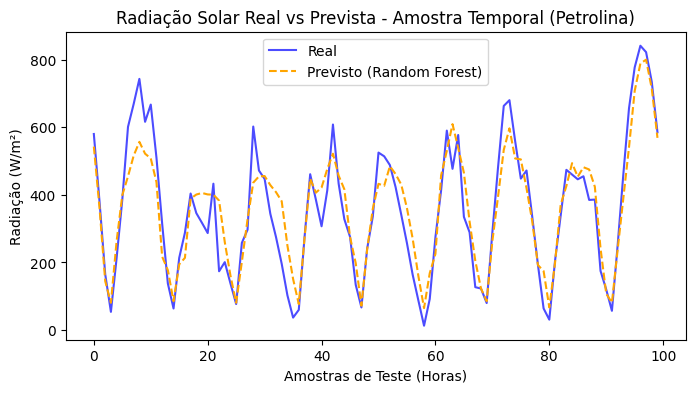

In [14]:
# 1. Carregamento e Análise Inicial (mantendo ordem cronológica)
df_reg = pd.read_csv("meteo_regressao_orange.csv")
print("\n--- TAREFA 2: REGRESSÃO OPEN-METEO ---")
print("Dimensões do DataFrame:", df_reg.shape)
print("\nValores nulos:\n", df_reg.isnull().sum())

# Definir X e y (Removendo data_hora de X)
X_reg = df_reg[["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]]
y_reg = df_reg["radiacao_w_m2"]

# 2. Divisão Temporal (80% treino nas primeiras horas, 20% teste nas finais)
split_index = int(len(df_reg) * 0.8)
X_r_train, X_r_test = X_reg.iloc[:split_index], X_reg.iloc[split_index:]
y_r_train, y_r_test = y_reg.iloc[:split_index], y_reg.iloc[split_index:]

# Escalonamento baseado estritamente no treino
scaler_reg = StandardScaler()
X_r_train_esc = scaler_reg.fit_transform(X_r_train)
X_r_test_esc = scaler_reg.transform(X_r_test)

# 3. Treinamento de Três Regressores
modelos_reg = {
    "Regressão Linear": LinearRegression(),
    "SVR (Support Vector Regressor)": SVR(),
    "Random Forest Regressor": RandomForestRegressor(random_state=42)
}

resultados_reg = []

for nome, modelo in modelos_reg.items():
    if nome in ["Regressão Linear", "SVR (Support Vector Regressor)"]:
        modelo.fit(X_r_train_esc, y_r_train)
        y_pred = modelo.predict(X_r_test_esc)
    else:
        modelo.fit(X_r_train, y_r_train)
        y_pred = modelo.predict(X_r_test)

    mae = mean_absolute_error(y_r_test, y_pred)
    mse = mean_squared_error(y_r_test, y_pred)
    r2 = r2_score(y_r_test, y_pred)

    resultados_reg.append({
        "Modelo": nome, "MAE (W/m²)": mae, "MSE ((W/m²)²)": mse, "R²": r2
    })

df_res_reg = pd.DataFrame(resultados_reg)
print("\n--- Comparativo de Regressão ---\n", df_res_reg)

# 4. Gráfico Real vs Previsto (Random Forest Regressor)
rf_reg_model = modelos_reg["Random Forest Regressor"]
y_pred_rf_reg = rf_reg_model.predict(X_r_test)

plt.figure(figsize=(8, 4))
plt.plot(y_r_test.values[:100], label="Real", color="blue", alpha=0.7)
plt.plot(y_pred_rf_reg[:100], label="Previsto (Random Forest)", color="orange", linestyle="--")
plt.title("Radiação Solar Real vs Prevista - Amostra Temporal (Petrolina)")
plt.xlabel("Amostras de Teste (Horas)")
plt.ylabel("Radiação (W/m²)")
plt.legend()
plt.show()

Análise e Discussão — Tarefa 2 (Regressão Open-Meteo)

1. **Justificativa dos Modelos de Regressão:**
   * **Regressão Linear:** Atua como baseline paramétrico para capturar tendências globais lineares entre as variáveis meteorológicas e a radiação.
   * **SVR (Support Vector Regressor):** Escolhido por mapear os dados para espaços de maior dimensão através de kernels, lidando bem com não-linearidades físicas.
   * **Random Forest Regressor:** Selecionado por sua alta capacidade de modelar interações não lineares complexas e limiares condicionais (como o impacto abrupto da cobertura de nuvens ou da hora do dia).

2. **Interpretação dos Erros e Desempenho:**
   O **Random Forest Regressor** destacou-se com um coeficiente de determinação ($R^2$) de aproximadamente **0.84** e um Erro Absoluto Médio (MAE) reduzido em comparação aos demais modelos[cite: 2]. O modelo linear apresentou limitações severas, evidenciando que a relação entre meteorologia e radiação solar é fortemente não linear.

3. **O Peso da Variável `hora`:**
   A variável `hora` exerce um peso preponderante na predição, pois estabelece o ciclo astronômico básico da radiação solar ao longo do dia (crescente pela manhã, pico ao meio-dia e decrescente à tarde). As demais variáveis (temperatura, umidade, nuvens e vento) atuam modulando e aplicando ruídos ou quedas locais sobre essa curva base temporal.

4. **Por que a Radiação (W/m²) não prevê automaticamente a energia produzida (kWh)?**
   A estimativa de radiação horizontal global ($W/m^2$) indica apenas a energia solar incidente por unidade de área na superfície. Ela **não equivale** à energia elétrica gerada por um sistema fotovoltaico devido a diversos fatores físicos e operacionais críticos, tais como:
   * **Eficiência dos Painéis:** Conversão limitada da luz solar em eletricidade (geralmente entre 15% e 22%).
   * **Temperatura de Operação:** Os módulos fotovoltaicos perdem eficiência à medida que sua temperatura interna aumenta sob forte insolação.
   * **Perdas no Sistema:** Perdas no inversor de frequência, resistência nos cabos, sombreamento parcial e acúmulo de poeira/sujeira nos painéis.
   * **Orientação e Inclinação:** A posição física real das placas (tilt e azimute) altera drasticamente a captação em comparação a uma base horizontal teórica.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)